In [2]:
from src.counterfactual_fraud_model.pipeline import OffPolicyEvaluationPipeline
from simulation_analysis import *

In [3]:
def run_simulations(exploration_rates: np.ndarray, 
                   cutoff: float = 0.05,
                   random_state: int = 42) -> tuple[List[Dict[str, Any]], pd.DataFrame]:
    """
    Run multiple OffPolicyEvaluationPipeline simulations with different exploration rates.
    
    Args:
        exploration_rates: Array of exploration rate values to test
        cutoff: Fixed cutoff value for all simulations
        random_state: Random seed for reproducibility
        
    Returns:
        Tuple of (list of simulation results, reference data for plots)
    """
    print(f"Running {len(exploration_rates)} simulations...")
    
    # Initialize pipeline with fixed parameters
    pipeline = OffPolicyEvaluationPipeline(
        random_state=random_state,
        # HACK PARAMETERS ADJUSTMENT
        # alpha=0.5,
        # beta_param=5.0,
        mean=-0.4,
        # sd=0.5,
        # sample_size=50_000,
        # n_bootstrap=5000,
    )
    
    # Get reference data (same for all simulations since we use same data generation params)
    reference_data = pipeline.generated_data
    
    results = []
    
    for i, exploration_rate in enumerate(exploration_rates):
        print(f"Running simulation {i+1}/{len(exploration_rates)} with exploration_rate={exploration_rate:.3f}")
        
        # Run pipeline with current exploration rate
        result = pipeline.run_pipeline(
            cutoff=cutoff,
            exploration_rate=exploration_rate,
            include_data=False  # Don't include data to save memory
        )
        
        # Add exploration_rate to result for easy tracking
        result['parameters']['exploration_rate'] = exploration_rate
        results.append(result)
    
    return results, reference_data

In [4]:
exploration_rates = np.linspace(0.01, 0.1, 10)
cutoff = 0.05
random_state = 42

# Run simulations
results, reference_data = run_simulations(exploration_rates, cutoff, random_state)

Running 10 simulations...
Running simulation 1/10 with exploration_rate=0.010
Running simulation 2/10 with exploration_rate=0.020
Running simulation 3/10 with exploration_rate=0.030
Running simulation 4/10 with exploration_rate=0.040
Running simulation 5/10 with exploration_rate=0.050
Running simulation 6/10 with exploration_rate=0.060
Running simulation 7/10 with exploration_rate=0.070
Running simulation 8/10 with exploration_rate=0.080
Running simulation 9/10 with exploration_rate=0.090
Running simulation 10/10 with exploration_rate=0.100


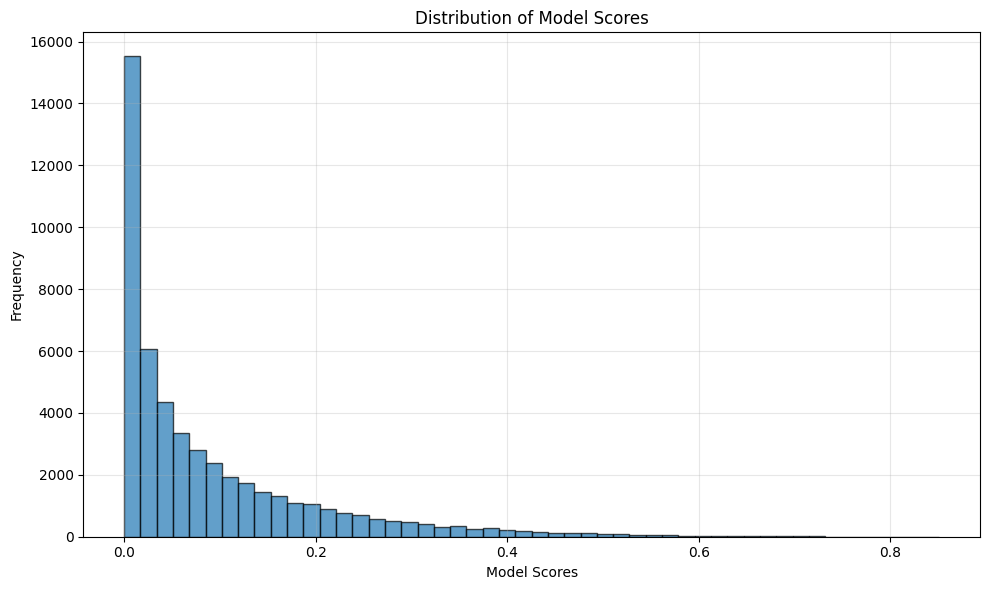

In [5]:
plot_model_scores_histogram(reference_data)

In [6]:
pipeline_params = results[0]['parameters']
summary_table = create_data_summary_table(reference_data, pipeline_params)
summary_table

,Metric,Value
0,Total Transactions,50000
1,True Fraud Rate,0.0845
2,Alpha,0.5
3,Beta,5.0
4,Mean,-0.4
5,SD,0.5
6,Sample Size,50000


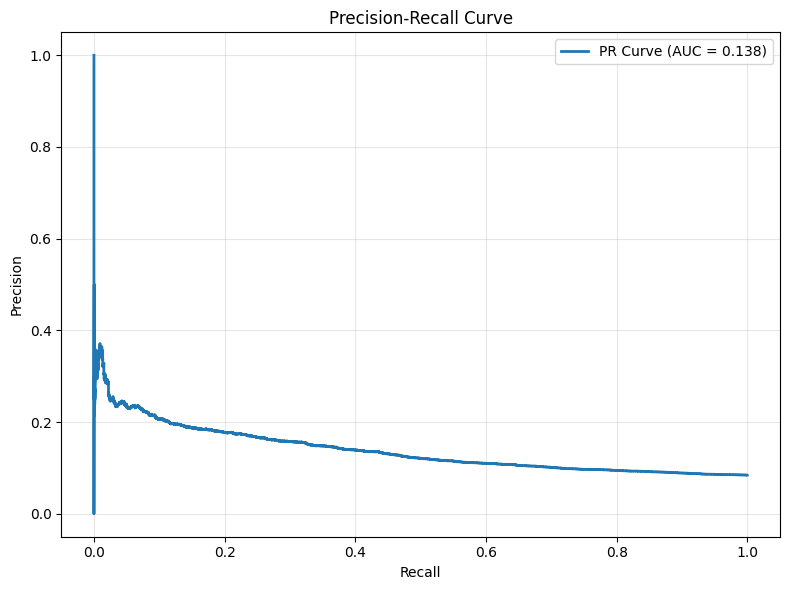

In [7]:
plot_precision_recall_curve(reference_data)

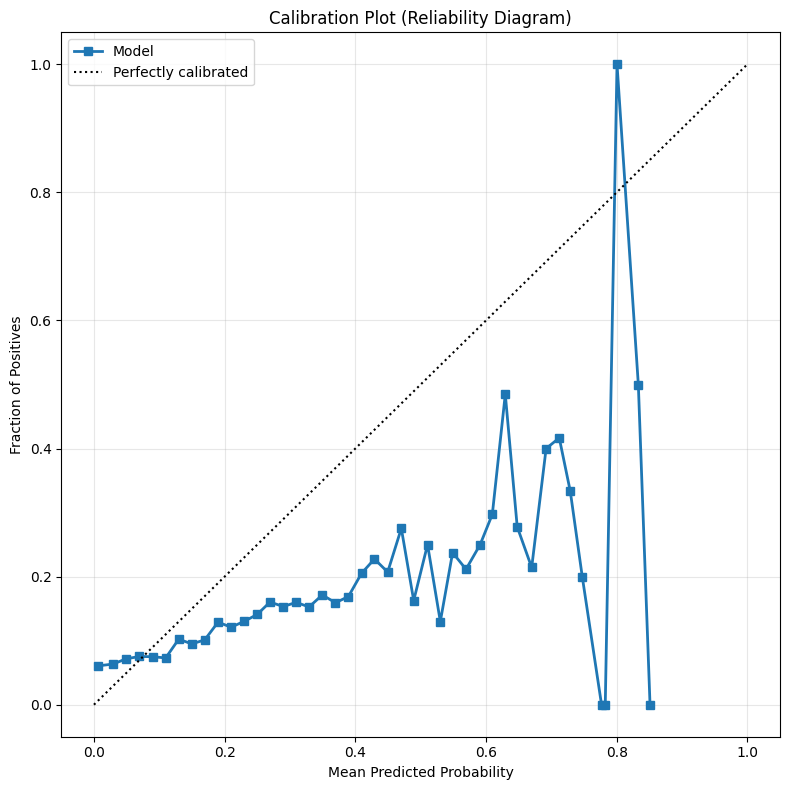

In [8]:
plot_calibration_curve(reference_data)

In [9]:
policy_table = create_policy_metrics_table(results)
policy_table

,exploration_rate,policy_approval_rate,policy_fraud_rate,approval_rate_increase,fraud_rate_increase
0,0.01,0.51866,0.062430,0.00464,0.000370
1,0.02,0.52354,0.062880,0.00952,0.000820
2,0.03,0.52810,0.063549,0.01408,0.001489
3,0.04,0.53288,0.063917,0.01886,0.001857
4,0.05,0.53770,0.064311,0.02368,0.002251
5,0.06,0.54288,0.064729,0.02886,0.002669
6,0.07,0.54804,0.065141,0.03402,0.003081
7,0.08,0.55354,0.065470,0.03952,0.003410
8,0.09,0.55856,0.065776,0.04454,0.003716
9,0.10,0.56310,0.066169,0.04908,0.004110


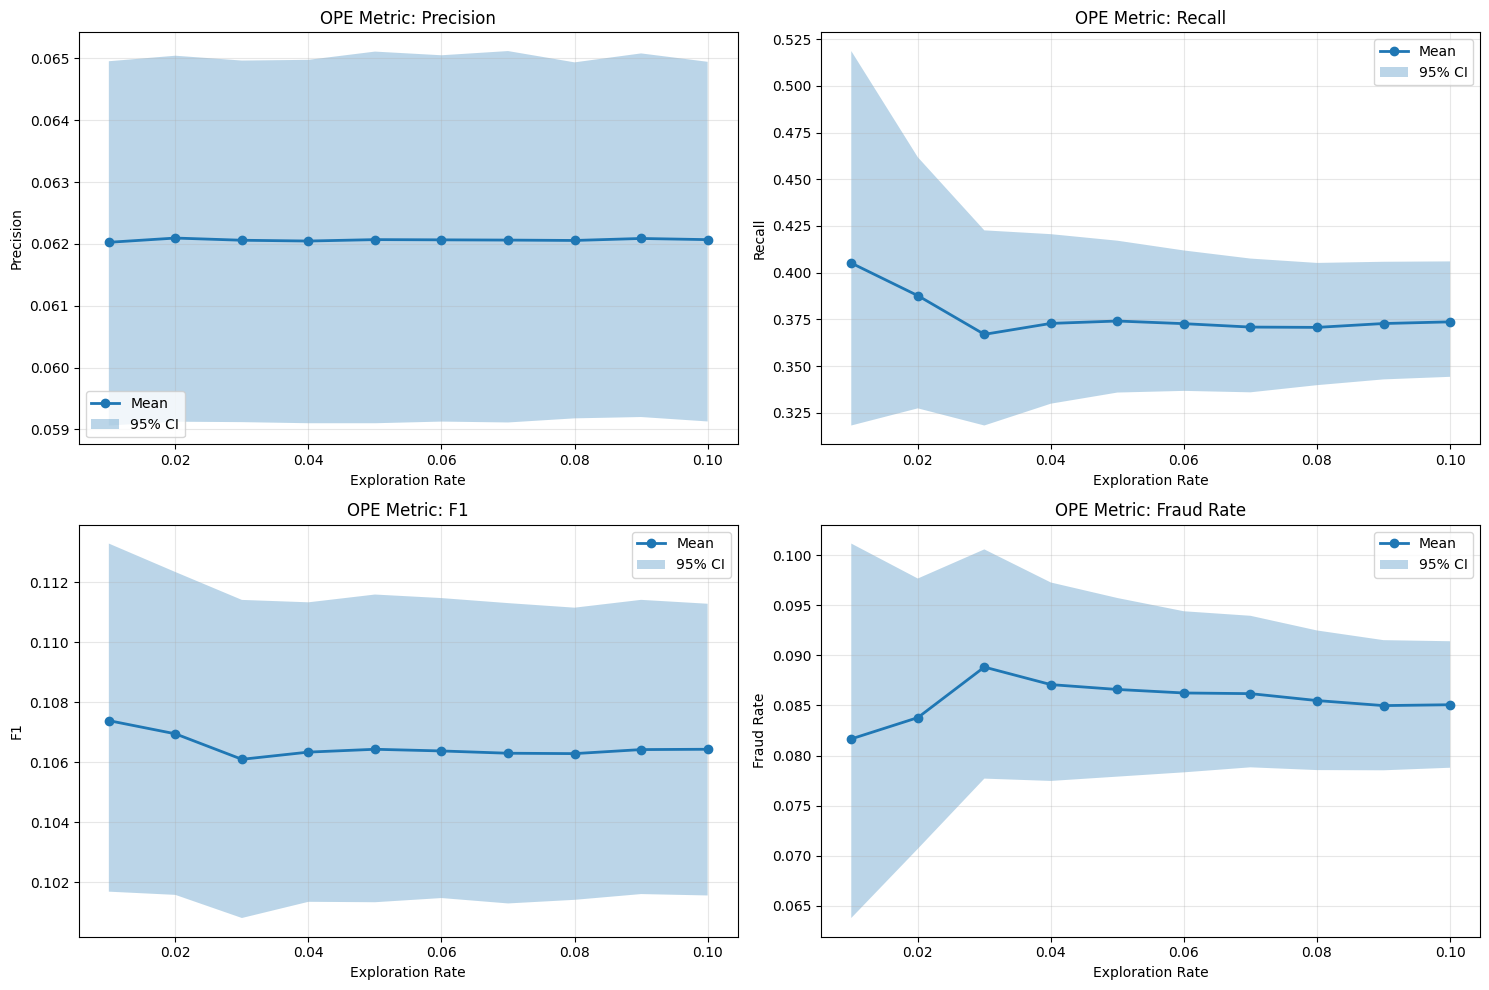

In [10]:
plot_ope_metrics(results)